In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline



In [2]:
def f(x):
    return 3*x**2 -4*x + 5
    

In [3]:
f(3.0)

20.0

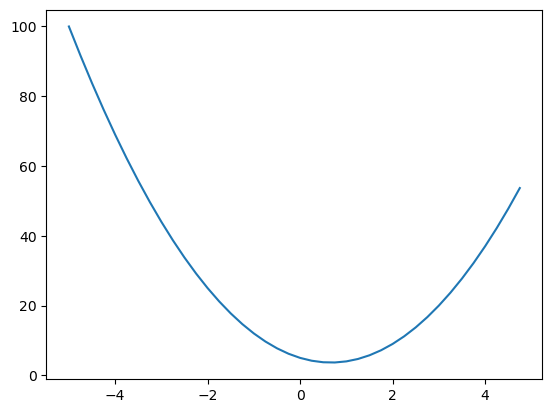

In [4]:
xs = np.arange(-5 ,5 ,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [5]:
h = 0.0001
x=-3.0
(f(x+h) - f(x) )/h

-21.999700000066014

In [6]:
a = 2.0
b =-3.0
c =10.0
d = a*b+c
print(d)

4.0


In [7]:
h = 0.001

a = 2.0
b =-3.0
c =10.0
d1 = a*b+c
b +=h
d2 = a*b +c

print("d1:",d1)
print("d2:",d2)
print("slope:", (d2-d1)/h)

d1: 4.0
d2: 4.002
slope: 1.9999999999997797


In [8]:
class Value:
    def __init__(self,data , _children=(),_op='' , label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"ValueData={self.data})"

    def __add__(self,other):
        other = other if isinstance(other , Value) else Value(other)
        out = Value(self.data + other.data , (self , other ) , '+')
        def _backward():
            self.grad += 1.0 *out.grad
            other.grad += 1.0 * out.grad
        out._backward =_backward
        return out
        
    def __radd__(self , other):
        return self + other

    def __mul__(self,other):
        other = other if isinstance(other , Value) else Value(other)
        out = Value(self.data * other.data, (self , other ) , '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward =_backward
        return out

    def __pow__(self , other):
        assert isinstance(other , (int,float)), "only supporting int/float powers for now"
        out =Value(self.data**other, (self,) , f'**{other}')
        def _backward():
            self.grad += other * (self.data **( other -1))  * out.grad
        out._backward = _backward
        return out
        
    def __rmul__(self , other):
        return self * other

    def __truediv__(self, other):
        return self * (other**(-1))  

    def __neg__(self):
        return self * -1
    def __sub__(self, other):
        return self + (-other)
        

    def tanh(self):
        x= self.data
        t= (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,{self,}, 'tanh')

        def _backward():
            self.grad += (1-t**2)*out.grad
        out._backward = _backward
        return out
        
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

        

        
    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
                
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

        



In [9]:
a = Value(4.0)
b = Value(2.0)
a-b

ValueData=2.0)

In [10]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes ,edges = set() ,set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format = 'svg',graph_attr={'rankdir':'LR'}) # LR = left to right

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        #for any value in graph, create a rectangular ('record') node for it
        dot.node(name = uid , label = "{ %s | data %.4f | grad =%.4f }" % (n.label,n.data,n.grad ), shape='record')
        if n._op:
            # if this value is a result of some operation, create a op node for it
            dot.node( name = uid + n._op, label = n._op)
            # and connect this to node
            dot.edge(uid + n._op, uid)

    for n1,n2 in edges:
        # connect n1 to op node of n2
        dot.edge(str(id(n1)), str(id(n2)) +n2._op)

    return dot

In [11]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights wl, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1. label = 'x1*w1'
x2w2 = x2*w2; x2w2. label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n. tanh(); o. Label = 'o'
o.backward()

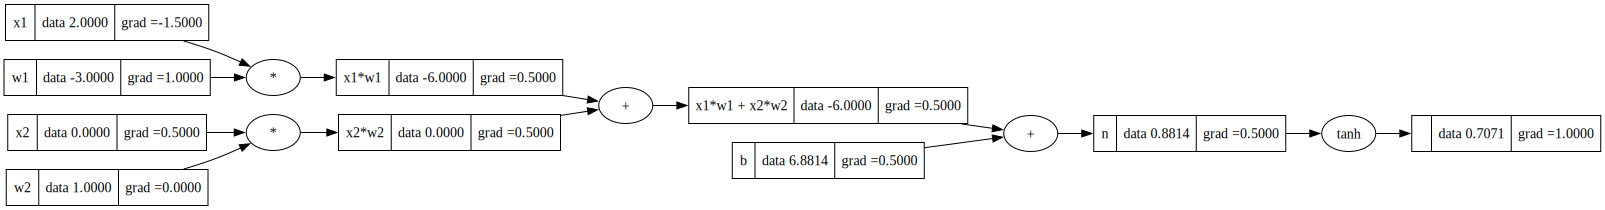

In [12]:
draw_dot(o)

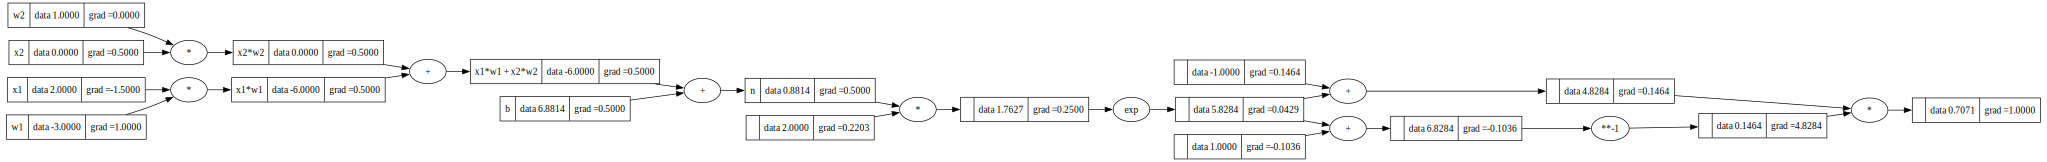

In [13]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights wl, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1. label = 'x1*w1'
x2w2 = x2*w2; x2w2. label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()
o = (e -1 )/( e + 1)
o. Label = 'o'


o.backward()
draw_dot(o)

In [24]:
import torch

x1 = torch.Tensor([2.0]).double()               ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()               ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()              ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()               ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 +x2*w2 +b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('x1',x1.grad.item())


0.7071066904050358
x1 -1.5000003851533106


In [60]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
         # w * x + b
        act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        

class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [76]:
x = [2.0 ,3.0 ,-1.0]
n  = MLP(1 , [4,4,1])

n(x)

ValueData=0.6457074886049858)

In [77]:
xs = [[2.0 ,3.0 ,-1.0],
     [3.0,-1.0,0.5],
     [0.5,1.0,1.0],
     [1.0,1.0,-1.0],
    ]
ys= [1.0,-1.0,-1.0,1.0]


In [79]:
for k in range(100):
    
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt , yout in zip(ys,ypred))

    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    
    for p in n.parameters():
        p.data += -0.05 * p.grad
        
        
    print(k,loss.data)


0 3.191490362127748
1 3.216792167221075
2 3.0976885913360315
3 3.1121156767565723
4 3.0049774033710315
5 3.0114042394887672
6 2.9174933458571934
7 2.9144895037368483
8 2.8321305763107216
9 2.8183618424827275
10 2.7480623771443615
11 2.726303333306026
12 2.664771361214575
13 2.6389729629929373
14 2.5797086251827577
15 2.5567448060730986
16 2.4909442799420716
17 2.4812026096432964
18 2.3966566250031613
19 2.412639852645876
20 2.295191036320042
21 2.3511411861391394
22 2.186242268033382
23 2.2967165534938165
24 2.071038952546242
25 2.2489144957422487
26 1.952767025128303
27 2.2077187149267443
28 1.8362332203117973
29 2.173216336589541
30 1.7264449359006107
31 2.1451437571653935
32 1.6271598129745115
33 2.1226266071478577
34 1.5402399109974791
35 2.1044041937753697
36 1.465941377379857
37 2.0893204877875586
38 1.4033786305560316
39 2.0762195617416146
40 1.351477888085333
41 2.06496736271883
42 1.307830258941659
43 2.0527763507915715
44 1.2751891379947178
45 2.0493519331958616
46 1.23278317